# Recognition of Heidelberg spiking digits using synaptic delays

This notebook is organized as follows:
- import libraries
- import SHD dataset and transform it to fit the network input format 
- generate input signal (pattern 1, pattern 2, pattern 1+2)
- build and run the network
- display the results

## Imports

In [ ]:
import tonic
import tonic.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import pyNN.nest as sim
import time
from pyNN.utility import ProgressBar
import logging
logging.getLogger('PyNN').setLevel(logging.CRITICAL)
from tqdm import tqdm
import scipy as sp
from numba import njit


## SHD dataset import and tranformation to fit network input format

### Functions to generate sequence of spikes (not used here) and generate signals from multiple patterns (successive and simultaneous)

In [47]:
@njit
def generate_random_sequence_spike_duration_constraint(sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[int], int]:
    """
        Generates a random list of spike timings

        Parameters
        ----------
        sequence_length : int
            maximum number of timings in the sequence
        min_time_interval : int
            minimum time interval between two successive timings
        max_time_interval : int
            maximum time interval between two successive timings
        period_length : int
            duration of the sequence (maximum timing in the sequence)

        Returns
        -------
        list_time_spike : list[int]
            list of spike timings
        int
            number of spikes in the sequence
        
    """
    time_spike = 0
    list_time_spike = np.zeros(sequence_length, dtype=np.int32)
    for i in range(sequence_length): 
        # the following timing is chosen as last timing plus a random integer between min_time_interval and max_time_interval
        time_spike = time_spike + np.random.randint(min_time_interval,max_time_interval)
        # we do not consider timings greater than period_length 
        if time_spike<period_length :
            list_time_spike[i] = time_spike
        else:
            return list_time_spike, i
    return list_time_spike, sequence_length

@njit
def input_spike_timing_multiple_periods_signal_generator(signal_spike_timings : list[int], num_spike_sequence : int, first_spike_time : int, num_periods : int, period_length : int) -> list[int]:
    """
        Generates a periodic sequence of spike timings based on a sequence of spike timings 

        Parameters
        ----------
        signal_spike_timings : list[int]
            list of spike timings
        num_spike_sequence : int
            number of spikes in the sequence
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods of the signal 
        period_length : int
            duration of the period

        Returns
        -------
        spike_timing_list : list[int]
            list of spike timings
    """
    spike_timing_list = np.zeros(num_periods*num_spike_sequence, dtype=np.int32)
    for i in range(num_periods):
        for j in range(num_spike_sequence):
            spike_timing_list[i*num_spike_sequence+j] = first_spike_time+period_length*i+signal_spike_timings[j]
    return spike_timing_list


@njit
def generate_multiple_random_sequence_spike_duration_constraint(num_sequence : int, sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generates a pattern of spike timings for several neurons. Each element of the output list corresponds to the spike timings for one neuron.

        Parameters
        ----------
        num_sequence : int
            number of random list to generate (or number of spiking neurons)
        sequence_length : int
            maximum number of timings in each sequence
        min_time_interval : int
            minimum time interval between two successive timings in each sequence
        max_time_interval : int
            maximum time interval between two successive timings in each sequence
        period_length : int
            duration of all sequences (maximum timing in each sequence)

        Returns
        -------
        list_time_spike : list[list[int]]
            list of list of spike timings (length equal to num_sequence)
        num_spike_sequence_list
            list of number of spikes in each sequence
    """
    spike_sequence_list = np.zeros((num_sequence, sequence_length), dtype=np.int32)
    num_spike_sequence_list = np.zeros(num_sequence, dtype=np.int32)
    for i in range(num_sequence):
        # generate one sequence of random numbers
        spike_sequence, num_spike_sequence = generate_random_sequence_spike_duration_constraint(sequence_length, min_time_interval, max_time_interval, period_length)
        spike_sequence_list[i] = spike_sequence
        num_spike_sequence_list[i] = num_spike_sequence
    return spike_sequence_list, num_spike_sequence_list

@njit
def generate_multiple_random_sequence_multiple_neurons_spike_duration_constraint(num_patterns : int, num_sequence : int, sequence_length : int, min_time_interval : int, max_time_interval : int, period_length : int) -> tuple[list[list[list[int]]], list[list[int]]]:
    """
        Generates multiple pattern of spike timings for several neurons. Each element of the output list corresponds to a pattern of spike timings for multiple neurons.

        Parameters
        ----------
        num_patterns : int
            number of random pattern to generate
        num_sequence : int
            number of random list to generate for one pattern (or number of spiking neurons)
        sequence_length : int
            maximum number of timings in each sequence of a pattern
        min_time_interval : int
            minimum time interval between two successive timings in each sequence of a pattern
        max_time_interval : int
            maximum time interval between two successive timings in each sequence of a pattern
        period_length : int
            duration of all sequences (maximum timing in each sequence) of a pattern

        Returns
        -------
        list_time_spike : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        num_spike_sequence_list : list[list[int]]
            list of list of number of spikes in each sequence of each pattern
    """
    signal_spike_timings_list = np.zeros((num_patterns, num_sequence, sequence_length), dtype=np.int32)
    num_spike_sequence_list = np.zeros((num_patterns, num_sequence), dtype=np.int32)
    for i in range(num_patterns):
        signal_spike_timings_list_i, num_spike_sequence_list_i = generate_multiple_random_sequence_spike_duration_constraint(num_sequence,sequence_length,min_time_interval,max_time_interval,period_length)
        signal_spike_timings_list[i] = signal_spike_timings_list_i
        num_spike_sequence_list[i] = num_spike_sequence_list_i
    return signal_spike_timings_list, num_spike_sequence_list

@njit
def multiple_input_spike_timing_multiple_periods_signal_generator(signal_spike_timings_list : list[list[int]], num_spike_sequence_list : list[int], first_spike_time : int, num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generates a periodic sequence of spike timings for multiple neurons based on a pattern of spike timings for several neurons. 

        Parameters
        ----------
        signal_spike_timings_list : list[list[int]]
            list of list of spike timings
        num_spike_sequence_list : list[int]
            list of number of spikes for each neuron
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods of the signal 
        period_length : int
            duration of the period

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings
        spike_num_list : list[int]
            list of number of spike in the signal for each neuron
    """
    num_neuron = len(signal_spike_timings_list)
    sequence_length = len(signal_spike_timings_list[0])
    spike_timing_matrix = np.zeros((num_neuron, sequence_length*num_periods),  dtype=np.int32)
    spike_num_list = np.zeros(num_neuron,  dtype=np.int32)
    for i in range(num_neuron):
        signal_spike_timings = signal_spike_timings_list[i]
        num_spike_sequence = num_spike_sequence_list[i]
        # generate a periodic sequence of spikes for each sequence of the list signal_spike_timings_list
        spike_timing_list = input_spike_timing_multiple_periods_signal_generator(signal_spike_timings, int(num_spike_sequence), first_spike_time, num_periods, period_length)
        spike_num = len(spike_timing_list)
        spike_timing_matrix[i, :spike_num] = spike_timing_list 
        spike_num_list[i] = spike_num
    return spike_timing_matrix, spike_num_list

@njit
def multiple_input_spike_timing_multiple_periods_multiple_signal_generator(multiple_signal_spike_timings_list : list[list[list[int]]], multiple_signal_num_spike_sequence_list : list[list[int]],  first_spike_time : int, num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generate a sequence of spike timings consisting of successive periodic sequences of spike timings for multiple neurons, each periodic sequence being based on a list of sequences of spike timings.
        For instance if a list composed of two sequences of spike, the function will return a sequence in wich the first sequence will be repeated num_periods times, followed by the second sequence repeated num_periods times.

        Parameters
        ----------
        multiple_signal_spike_timings_list : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        first_spike_time : int
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods for each sequence of the signal 
        period_length : int
            duration of the period for each sequence of the signal

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings (each element is the spike timings for one neuron)
        last_spike_index : list[int]
            list of number of spike in the signal for each neuron
    """
    num_pattern = len(multiple_signal_spike_timings_list)
    num_neuron = len(multiple_signal_spike_timings_list[0])
    sequence_length = len(multiple_signal_spike_timings_list[0][0])
    spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    last_spike_index = np.zeros(num_neuron, dtype=np.int32)
    for i in range(num_pattern):
        # for each pattern, generate a periodic signal from this pattern, and then concatenate the signals
        spike_timing_matrix_i, spike_num_list = multiple_input_spike_timing_multiple_periods_signal_generator(multiple_signal_spike_timings_list[i], multiple_signal_num_spike_sequence_list[i], first_spike_time+i*(period_length*num_periods), num_periods, period_length) 
        for j in range(num_neuron):
            num_spike_j = int(spike_num_list[j])
            new_last_index = last_spike_index[j] + num_spike_j
            spike_timing_matrix[j, int(last_spike_index[j]):int(new_last_index)] = spike_timing_matrix_i[j,:num_spike_j]
            last_spike_index[j] = new_last_index
    return spike_timing_matrix, last_spike_index

@njit
def multiple_superimposed_input_spike_timing_multiple_signal_generator(multiple_signal_spike_timings_list : list[list[list[int]]], multiple_signal_num_spike_sequence_list : list[list[int]],  first_spike_time_list : list[int], num_periods : int, period_length : int) -> tuple[list[list[int]], list[int]]:
    """
        Generate a sequence of spike timings consisting of successive periodic sequences of spike timings for multiple neurons, each periodic sequence being based on a list of sequences of spike timings.
        For instance if a list composed of two sequences of spike, the function will return a sequence in wich the first sequence will be repeated num_periods times, followed by the second sequence repeated num_periods times.

        Parameters
        ----------
        multiple_signal_spike_timings_list : list[list[list[int]]]
            list of list of list of spike timings, each element of the list represents a sequence of spike timings for several neurons
        first_spike_time_list : list[int]
            start timing of the sequence (sequence can not start at 0 ms using nest)
        num_periods : int
            number of periods for each sequence of the signal 
        period_length : int
            duration of the period for each sequence of the signal

        Returns
        -------
        spike_timing_matrix : list[list[int]]
            list of list of spike timings (each element is the spike timings for one neuron)
        last_spike_index : list[int]
            list of number of spike in the signal for each neuron
    """
    num_pattern = len(multiple_signal_spike_timings_list)
    num_neuron = len(multiple_signal_spike_timings_list[0])
    sequence_length = len(multiple_signal_spike_timings_list[0][0])
    spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    last_spike_index = np.zeros(num_neuron, dtype=np.int32)
    sorted_spike_timing_matrix = np.zeros((num_neuron, num_pattern*sequence_length*num_periods),  dtype=np.int32)
    for i in range(num_pattern):
        # for each pattern, generate a periodic signal from this pattern, and then concatenate the signals
        spike_timing_matrix_i, spike_num_list = multiple_input_spike_timing_multiple_periods_signal_generator(multiple_signal_spike_timings_list[i], multiple_signal_num_spike_sequence_list[i], first_spike_time_list[i], num_periods, period_length) 
        for j in range(num_neuron):
            num_spike_j = int(spike_num_list[j])
            new_last_index = last_spike_index[j] + num_spike_j
            spike_timing_matrix[j, int(last_spike_index[j]):int(new_last_index)] = spike_timing_matrix_i[j,:num_spike_j]
            last_spike_index[j] = new_last_index
            if i == num_pattern-1:
                sorted_spike_timing_matrix[j, :int(new_last_index)] = np.sort(spike_timing_matrix[j, :int(new_last_index)])
    return sorted_spike_timing_matrix, last_spike_index

### Import SHD dataset, downsample it and transform it into the network defined format

In [ ]:
#load shd dataset from tonic
dataset = tonic.datasets.SHD(save_to="../tutorials/dataSHD", train=False)
time_factor_downsample = 0.001
# function for downsamplind the data
transform_fun = transforms.Downsample(time_factor = time_factor_downsample)
size_images = dataset.sensor_size
num_sequences = size_images[0]
images_for_network = []
num_spike_neurons_image = []
labels = []
# number of patterns to generate for the test
num_patterns_generate = 2
# maximum spike for 1 neuron of a pattern
max_spike_neuron = 1000
# minimum interspike interval
min_intervall_spike = 5
# duration of a pattern
period_length = int(800000*time_factor_downsample*min_intervall_spike)
# select two random patterns
patterns_to_learn = np.random.randint(0,len(dataset),num_patterns_generate)
for k in patterns_to_learn:
    # spike timing matrix
    image_for_network_k = np.zeros((num_sequences, max_spike_neuron), dtype=np.int32)
    # list giving the number of spikes for each neuron
    num_spike_neurons_image_k = np.zeros(num_sequences, dtype = np.int32)
    # get labels
    label = dataset[k][1]
    labels.append(label)
    # apply downsampling to each pattern and tranform each event in the network format
    for (t, i, p) in transform_fun(dataset[k][0]):
        # p always equal to 1 for sound but not for event based camera. If spikes occur after the defined duration, we remove them
        if p==1 and min_intervall_spike*t <= period_length:
            # we multiply the time of a spike by min_intervall_spike, to ensure a minimum interspike interval
            image_for_network_k[i][num_spike_neurons_image_k[i]] = min_intervall_spike*t
            num_spike_neurons_image_k[i] += 1
    images_for_network.append(image_for_network_k)
    num_spike_neurons_image.append(num_spike_neurons_image_k)



### Plot the patterns

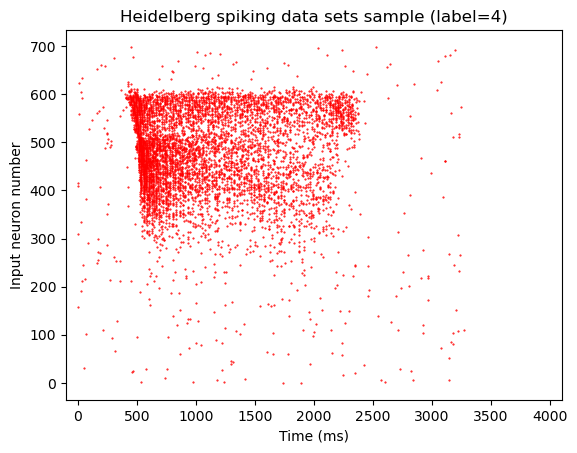

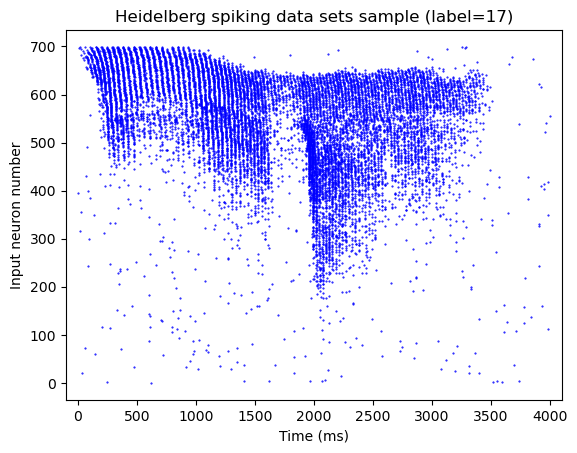

In [49]:
num_number_plot = 2
color_list = ['r', 'b'] 
for image_i in range(num_number_plot) : 
    plt.figure()
    for neuron_i in range(num_sequences):
        if neuron_i == 0:
            plt.scatter(images_for_network[image_i][neuron_i][:num_spike_neurons_image[image_i][neuron_i]],neuron_i*np.ones(num_spike_neurons_image[image_i][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1, label = labels[image_i])
        else : 
            plt.scatter(images_for_network[image_i][neuron_i][:num_spike_neurons_image[image_i][neuron_i]],neuron_i*np.ones(num_spike_neurons_image[image_i][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1)
    plt.xlabel('Time (ms)')
    plt.ylabel('Input neuron number')
    plt.title('Heidelberg spiking data sets sample (label='+str(labels[image_i])+')')
    plt.xlim([-20000*time_factor_downsample*min_intervall_spike, 820000*time_factor_downsample*min_intervall_spike])


### Plot the two simultaneous patterns

First with colors to distinguish the two patterns, then with no colour

(-100.0, 4100.0)

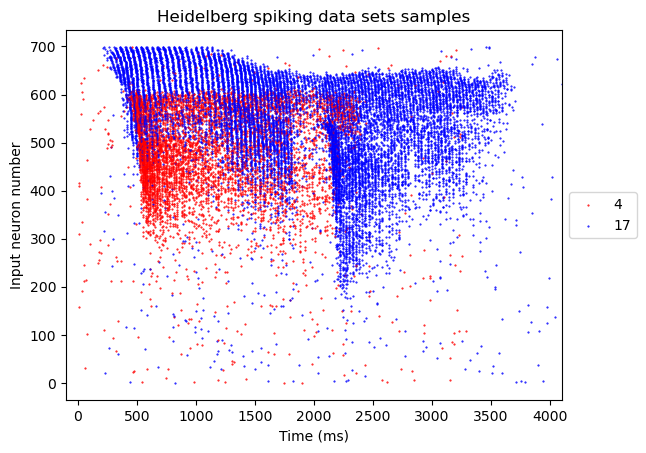

In [ ]:
num_number_plot = 2
color_list = ['r', 'b'] 
# list of delays between each pattern 
first_spike_time_list = [10, int(200000*time_factor_downsample)]
for neuron_i in range(num_sequences):
    for image_i in range(num_number_plot) : 
        if neuron_i == 0:
            plt.scatter(images_for_network[image_i][neuron_i][:num_spike_neurons_image[image_i][neuron_i]]+first_spike_time_list[image_i]*np.ones(num_spike_neurons_image[image_i][neuron_i]),neuron_i*np.ones(num_spike_neurons_image[image_i][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1, label = labels[image_i])
        else : 
            plt.scatter(images_for_network[image_i][neuron_i][:num_spike_neurons_image[image_i][neuron_i]]+first_spike_time_list[image_i]*np.ones(num_spike_neurons_image[image_i][neuron_i]),neuron_i*np.ones(num_spike_neurons_image[image_i][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1)

plt.xlabel('Time (ms)')
plt.ylabel('Input neuron number')
plt.title('Heidelberg spiking data sets samples')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlim([-20000*time_factor_downsample*min_intervall_spike, 820000*time_factor_downsample*min_intervall_spike])




Text(0.5, 1.0, 'Heidelberg spiking data sets samples')

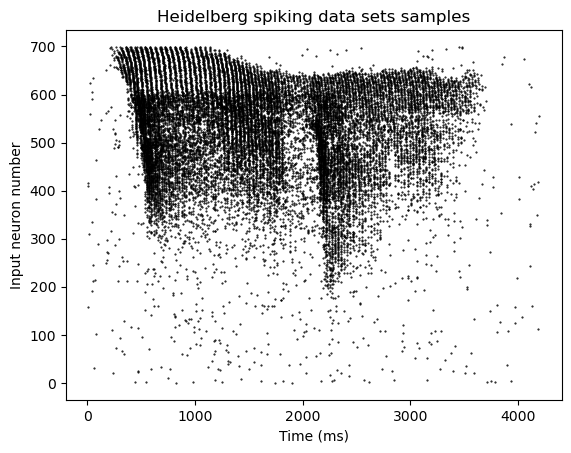

In [ ]:
# simultaneous patterns signal given as input to the network
sorted_spike_timing_matrix, last_spike_index = multiple_superimposed_input_spike_timing_multiple_signal_generator(images_for_network, num_spike_neurons_image, first_spike_time_list, num_periods = 1, period_length = period_length)

for neuron_i in range(num_sequences):
    plt.scatter(sorted_spike_timing_matrix[neuron_i][:last_spike_index[neuron_i]],neuron_i*np.ones(last_spike_index[neuron_i]), marker='.', s=1, c='k', alpha=1)

plt.xlabel('Time (ms)')
plt.ylabel('Input neuron number')
plt.title('Heidelberg spiking data sets samples')
#plt.xlim(100000, 100500)

### Generate the input signal for the network (pattern 1, pattern 2, pattern 1+2)

In [52]:
first_time_spike = 10
images_for_network.append(np.ascontiguousarray(sorted_spike_timing_matrix[:, :max_spike_neuron]))
num_spike_neurons_image.append(last_spike_index)
final_spike_timing_matrix, finnal_last_spike_index = multiple_input_spike_timing_multiple_periods_multiple_signal_generator(images_for_network, num_spike_neurons_image, first_time_spike, 1, period_length)

### Plot input signal
First without colors then with colors to distinguish each pattern

Text(0.5, 1.0, 'Heidelberg spiking data sets samples')

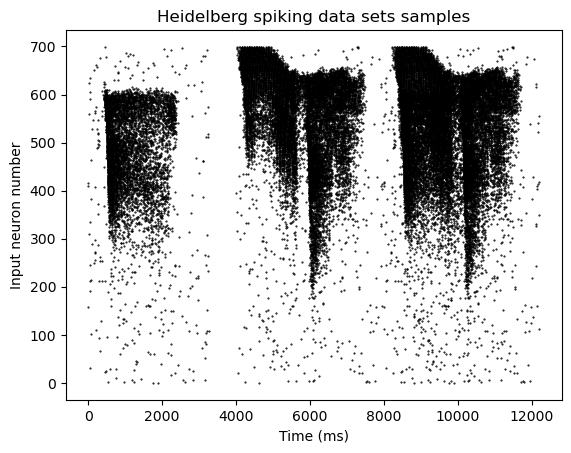

In [53]:
for neuron_i in range(num_sequences):
    plt.scatter(final_spike_timing_matrix[neuron_i][:finnal_last_spike_index[neuron_i]],neuron_i*np.ones(finnal_last_spike_index[neuron_i]), marker='.', s=1, c='k', alpha=1)

plt.xlabel('Time (ms)')
plt.ylabel('Input neuron number')
plt.title('Heidelberg spiking data sets samples')
#plt.xlim(100000, 100500)

(-500.0, 12500.0)

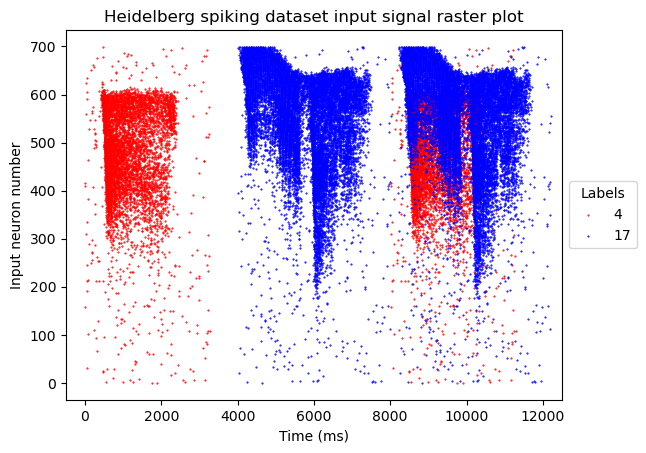

In [72]:
num_impage_plot = 4
number_plot_list = [0, 1, 0, 1]
color_list = ['r', 'b', 'r', 'b'] 
first_spike_time_list_list = [first_time_spike, first_time_spike+period_length, first_time_spike+ 2*period_length + first_spike_time_list[0], first_time_spike+ 2*period_length + first_spike_time_list[1]]
for image_i in range(num_impage_plot):
    image_i_id = number_plot_list[image_i]
    for neuron_i in range(num_sequences):
        if neuron_i == 0 and image_i < num_impage_plot//2:
            plt.scatter(images_for_network[image_i_id][neuron_i][:num_spike_neurons_image[image_i_id][neuron_i]]+first_spike_time_list_list[image_i]*np.ones(num_spike_neurons_image[image_i_id][neuron_i]),neuron_i*np.ones(num_spike_neurons_image[image_i_id][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1, label = labels[image_i_id])
        else : 
            plt.scatter(images_for_network[image_i_id][neuron_i][:num_spike_neurons_image[image_i_id][neuron_i]]+first_spike_time_list_list[image_i]*np.ones(num_spike_neurons_image[image_i_id][neuron_i]),neuron_i*np.ones(num_spike_neurons_image[image_i_id][neuron_i]), marker='.', s=1, c=color_list[image_i], alpha=1)

plt.xlabel('Time (ms)')
plt.ylabel('Input neuron number')
plt.title('Heidelberg spiking dataset input signal raster plot')
plt.legend(title = 'Labels', loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlim([-500, 12500])


## Spiking Neural Network Class

### Progress bar for pyNN simulation

In [55]:
class MyProgressBar(object):
    """
    A callback which draws a progress bar in the terminal.
    """
    
    def __init__(self, interval, t_stop):
        self.interval = interval
        self.t_stop = t_stop
        self.pb = ProgressBar(width=int(t_stop / interval), char=".")
        
    def __call__(self, t):
        self.pb(t / self.t_stop)
        return t + self.interval

### Function to create connections of the pattern recognition network based on a pattern of spike

In [56]:
@njit
def syn_weight_delay_from_spike_timings(period_length : int, num_interval : int, signal_spike_timings_list : list[list[list[int]]], index_last_spike_timings_list : list[list[int]],  synaptic_weight : int, sequence_weight_factor : int, pattern_num : int) -> tuple[int, int, list[list[float]], list[list[float]]]:
    
    """
        Creates a set of weights and delays to construct a pattern recognition SNN

        Parameters
        ----------
        period_length : int
            period length of the signals
        num_interval : int
            number of interval to divide the period of the signals (or number of output neurons for each learned signal)
        signal_spike_timings_list : list[list[list[int]]]
            patterns of spike timings used to construct the network
        index_last_spike_timings_list : list[list[int]]
            list giving for each pattern in signal_spike_timings_list the number of spikes for each neuron
        synaptic_weight : int
            synaptic weight necessary for generating one spike from one input spike
        sequence_weight_factor : int
            ratio of output-output synaptic weight to input-output synaptic weight
        pattern_num : int
            index of the pattern to recognize in the list signal_spike_timings_list
        
        Returns
        -------
        num_neuron_input : int
            number of input neurons in the network
        num_neuron_output : int
            number of output neurons in the network
        input_output_syn_weight_delay_list : list[list[float]]
            list of connections from input to output neurons, each element of the list is a 4 elements list 
            [input neuron id of input population, output neuron id of output population, synaptic weight, synaptic delay]
        output_output_syn_weight_delay_list : list[list[float]]
            list of connections from output to output neurons, each element of the list is a 4 elements list
            [input neuron id of output population, output neuron id of output population, synaptic weight, synaptic delay]
    """
    # time length of each sub interval of the sequence period  
    time_interval_length = int(period_length // num_interval)
    # number of input neurons in the sequence
    num_sequence = len(signal_spike_timings_list[pattern_num])
    #list of connections from input to output neurons
    length_output_list = np.sum(index_last_spike_timings_list[pattern_num])
    input_output_syn_weight_delay_list = np.empty((int(length_output_list),4), dtype = np.float32)
    #list to count the number of input to output connection
    counter_list = np.zeros(num_interval)
    # create connections from each input neuron to the output neurons 
    list_index_incr = 0 
    for i in range(num_sequence):
        num_spike_i = int(index_last_spike_timings_list[pattern_num][i])
        for j in range(num_spike_i):
        # create a connection for each spike of an input neuron
            spike_timing = int(signal_spike_timings_list[pattern_num][i][j])
            # the output neuron is selected depending on the timing of the spike 
            output_neuron = spike_timing // time_interval_length
            # the synaptic delay is chosen depending on the timing of a spike with respect to the time interval in which it occurs
            synaptic_delay = time_interval_length - spike_timing % time_interval_length
            # create a connection tuple with default weight (1 input spike generates 1 output spike), the weight value will be reduced after based on the number of input to output connections
            input_output_syn_weight_delay_list[list_index_incr, 0] = i
            input_output_syn_weight_delay_list[list_index_incr, 1] = output_neuron
            input_output_syn_weight_delay_list[list_index_incr, 2] = synaptic_weight
            input_output_syn_weight_delay_list[list_index_incr, 3] = synaptic_delay
            # increment the connection to output_neuron counter
            counter_list[output_neuron] += 1
            list_index_incr +=1
    
    # define first output neuron having non zero connection
    first_neuron = 0            
    while counter_list[first_neuron] == 0:
        first_neuron+=1
    # update weights based on the number of connections to each output neurons, so that output neuron fires only if all input spike arrive synchronously
    num_connections = len(input_output_syn_weight_delay_list)
    for i in range(num_connections):
        # if the output neuron is the first of a sequence to spike, then we divide the weight by the number of connections
        if input_output_syn_weight_delay_list[i,1] == first_neuron:
            new_weight = input_output_syn_weight_delay_list[i,2] / counter_list[int(input_output_syn_weight_delay_list[i][1])]
        # if the output neuron is not the first of a sequence to spike, then we divide the weight by the number of connections plus the output to output connection which relative weight is given by the variable sequence_weight_force
        else:
            new_weight = input_output_syn_weight_delay_list[i,2] / (sequence_weight_factor+counter_list[int(input_output_syn_weight_delay_list[i][1])])
        #replace connection weight
        input_output_syn_weight_delay_list[i,2] = new_weight
    # create connections from the output neurons to the output neurons
    
    output_output_syn_weight_delay_list = np.empty((num_interval-1-first_neuron,4), dtype = np.float32)
    # iterate over the output neurons
    for i in range(first_neuron, num_interval-1):
        # presynaptic neuron
        pre_neuron = i
        # postsynaptic neuron
        post_neuron= i+1
        # for all other neuron of the sequence the weight is similar to that of input to output connections with a factor self.args.sequence_weight_factor to avoid neurons from spiking outside of a sequence
        weight = sequence_weight_factor*synaptic_weight / (sequence_weight_factor+counter_list[post_neuron])
        # the delay is given by the length of a time subdivision of the signal period. The -1 compensates for the time generation of a spike by the neuron
        syn_delay = time_interval_length-1
        output_output_syn_weight_delay_list[i-first_neuron,0] = pre_neuron
        output_output_syn_weight_delay_list[i-first_neuron,1] = post_neuron
        output_output_syn_weight_delay_list[i-first_neuron,2] = weight
        output_output_syn_weight_delay_list[i-first_neuron,3] = syn_delay
    num_neuron_input = num_sequence
    num_neuron_output = num_interval
    return num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list, output_output_syn_weight_delay_list

### Class to create a pattern recognition network, simulate and analyse its results

In [ ]:
class Multiple_Neuron_Pattern_Detector():
    """
    A class to create and simulate a pattern detection SNN

    Attributes
    ----------
    args : dataclass Params
        parameters for creating and simulating the SNN:
            num_interval : int                    
                number of interval to divide the period of the signals (or number of output neurons for each learned signal)
            period_length : float                  
                length of the period of the signals
            synaptic_weight : float                
                synaptic weight necessary for generating one spike from one input spike
            signal_spike_timings_list : list                            
                patterns of spike timings used to construct the network
            timestep : float                       
                timestep of the simulation
            simulation_duration : float    
                duration of the simulation
            verbose : bool                         
                displays more verbose output
            sequence_weight_factor : int  
                ratio of output-output synaptic weight to input-output synaptic weight

    Methods
    -------
    build(sim, multiple_input_spike_timing_list)
        Creates a SNN to recognize several sequences of spike
    add_spike_signal_single_neuron(sim, pop_name, neuron_id, spike_times, spike_weight)
        Adds a sequence of input spike to a single neuron
    syn_weight_delay_from_spike_timings(pattern_num)
        Creates a set of weights and delays to construct a pattern recognition SNN
    run(sim, input_spike_timing_list)
        Creates and simulate a pattern detection SNN
   """

    def __init__(self, args):
        """
        Parameters
        ----------
        args : dataclass Params
            parameters for creating and simulating the SNN:
                num_interval : int                    
                    number of interval to divide the period of the signals (or number of output neurons for each learned signal)
                period_length : float                  
                    length of the period of the signals
                synaptic_weight : float                
                    synaptic weight necessary for generating one spike from one input spike
                signal_spike_timings_list : list                            
                    patterns of spike timings used to construct the network
                timestep : float                       
                    timestep of the simulation
                simulation_duration : float    
                    duration of the simulation
                verbose : bool                         
                    Displays more verbose output.
        """
        self.args : Params = args


    def build(self, sim, multiple_input_spike_timing_list, last_spike_index_list):
        """
            Creates a SNN to recognize several sequences of spike. The network structured is created based on args.signal_spike_timings_list

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            multiple_input_spike_timing_list : list[list[list[int]]]
                input signal to the network
        """
        print('build start')
        # get number of input neurons from one of the patterns to create the input population 
        num_neuron_input, _, _, _ = self.syn_weight_delay_from_spike_timings_class_function(pattern_num=0)
        start = time.time()
        ###---POPULATIONS OF THE NETWORK-------------------------------------------------------
        self.pops = {}

        ###---CELL PARAMETERS-------------------------------------------------------------------------------
        
        v_init=-65.0      #initial membrane potential of the neurons
        tau_m = 1.0       #membrane time constant of the neurons (here for fast dynamic neuron)
        tau_refrac = 2  #refractory time of the input neurons, we chose a relatively long time to avoid excessive spiking of neurons (no inhibition in this network)
        cell_initial_values = {
                'v' : v_init
                }
        tau_refrac_output = 2 #refractory time of the output neurons, we chose a relatively long time to avoid excessive spiking of neurons (no inhibition in this network)

        # Input excitatory neurons
        self.pops['input'] = sim.Population(num_neuron_input, sim.IF_curr_alpha(tau_m=tau_m, tau_refrac=tau_refrac), 
                                        initial_values=cell_initial_values, label="input")
        # Record spikes and membrane potential
        self.pops['input'].record(['spikes','v'])

        # Number of pattern to recognize
        tot_pattern = len(self.args.signal_spike_timings_list)

        # Create output neurons and synapses to recognize each pattern 
        ###---PROJECTIONS OF THE NETWORK---------------------------------------------------
        self.projs = {}
        for pattern_num in range(tot_pattern):
            # Get network parameters for recognition of the pattern
            num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list, output_output_syn_weight_delay_list = self.syn_weight_delay_from_spike_timings_class_function(pattern_num=pattern_num)
            
            # Create output neurons
            self.pops['output'+str(pattern_num)] = sim.Population(num_neuron_output, sim.IF_curr_alpha(tau_m=tau_m, tau_refrac=tau_refrac_output), 
                                            initial_values=cell_initial_values, label="output"+str(pattern_num))
            # Record only spike here, for faster code
            self.pops['output'+str(pattern_num)].record(['spikes','v'])

            # Static synapse, no learning here
            syn = sim.StaticSynapse()
            # Connect input neurons to output neurons from the list input_output_syn_weight_delay_list 
            connector_in_out = sim.FromListConnector(input_output_syn_weight_delay_list, column_names=["weight", "delay"])
            self.projs['in_out'+str(pattern_num)] = sim.Projection(self.pops['input'], self.pops['output'+str(pattern_num)], connector_in_out, syn, receptor_type='excitatory', label="in_out_connections"+str(pattern_num))
            # Connect output neurons to output neurons from the list output_output_syn_weight_delay_list
            connector_out_out = sim.FromListConnector(output_output_syn_weight_delay_list, column_names=["weight", "delay"])
            self.projs['out_out'+str(pattern_num)] = sim.Projection(self.pops['output'+str(pattern_num)], self.pops['output'+str(pattern_num)], connector_out_out, syn, receptor_type='excitatory', label="out_out_connections"+str(pattern_num))

        # Add input spike to input neuron from the list multiple_input_spike_timing_list
        for i in range(num_neuron_input):
            num_spike_neuron_i = last_spike_index_list[i]
            input_spike_timing_list = multiple_input_spike_timing_list[i][:num_spike_neuron_i]
            self.add_spike_signal_single_neuron(sim, 'input', i, input_spike_timing_list, self.args.synaptic_weight)

        end = time.time()
        if self.args.verbose: print(f'build step: {end-start:.3f}')
    

    def add_spike_signal_single_neuron(self, sim, pop_name, neuron_id, spike_times, spike_weight):
        """
            Adds a sequence of input spike to a single neuron of a population

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            pop_name : string
                name of the population 
            neuron_id : int
                id of the neuron to which we input a sequence of spikes
            spike_times : list[int]
                list of input spike times 
            spike_weight : float
                synaptic weight necessary for generating one spike from one input spike
                
        """
        # Create a spiking population of one neuron
        input_spike = sim.Population(1, sim.SpikeSourceArray(spike_times=spike_times), label="input spike")
        # Connect the spiking population to the neuron
        syn_spike_input = sim.StaticSynapse(weight=spike_weight)                    
        connections_input_stim_neuron = sim.Projection(input_spike, self.pops[pop_name][neuron_id:neuron_id+1], sim.FixedNumberPreConnector(1), syn_spike_input, receptor_type='excitatory')


    def syn_weight_delay_from_spike_timings_class_function(self, pattern_num):
        """
            Creates a set of weights and delays to construct a pattern recognition SNN

            Parameters
            ----------
            pattern_num : int
                index of the pattern to recognize in the list signal_spike_timings_list
            
            Returns
            -------
            num_neuron_input : int
                number of input neurons in the network
            num_neuron_output : int
                number of output neurons in the network
            input_output_syn_weight_delay_list_tuples : list[tuples]
                list of connections from input to output neurons, each element of the list is a 4 elements tuple 
                (input neuron id of input population, output neuron id of output population, synaptic weight, synaptic delay)
            output_output_syn_weight_delay_list_tuples : 
                list of connections from output to output neurons, each element of the list is a 4 elements tuple
                (input neuron id of output population, output neuron id of output population, synaptic weight, synaptic delay)
        """
        
        num_neuron_input, num_neuron_output, input_output_syn_weight_delay_list_list, output_output_syn_weight_delay_list_list = syn_weight_delay_from_spike_timings(self.args.period_length, self.args.num_interval, self.args.signal_spike_timings_list, self.args.signal_num_spike_timings_list,  self.args.synaptic_weight, self.args.sequence_weight_factor, pattern_num)
        input_output_syn_weight_delay_list_tuples = [(int(row[0]), int(row[1]), row[2], int(row[3])) for row in input_output_syn_weight_delay_list_list]
        output_output_syn_weight_delay_list_tuples = [(int(row[0]), int(row[1]), row[2], int(row[3])) for row in output_output_syn_weight_delay_list_list]
        return int(num_neuron_input), int(num_neuron_output), input_output_syn_weight_delay_list_tuples, output_output_syn_weight_delay_list_tuples
    
    def simulation_pattern_detection_analysis(self):
        """
            Analyses the results of the simulation (number of pattern detected, true positive, false negative etc..)

            Parameters
            ----------
            num_period : int
                number of periods for each spike pattern in the input signal
            first_spike_time_list : list[int]
                timing of the first spike of the input signal 
            num_pattern_analysis : int
                number of pattern to analyse (less or equal to the total number of patterns generated)
            num_pattern_test_input : int
                number of patterns that were given as input of the network for the test
            Returns
            -------
            pattern_detection_dict : dict
                dictionnary giving the spike timing of each pattern recognition output 
                dictionnary's key corresponds to the id of the recognized pattern and value is a list of timings corresponding to the recognition of the pattern
            num_spike_dict : dict
                dictionnary giving the number of activation of pattern recognition output
                dictionnary's key is the number of times a pattern was detected, and value is the number pattern recognized key number of times
            pattern_detection_analysis_dict : dict
                dictionnary giving the number of true positive, false positive and false negavtive pattern detection
            wrong_pattern_activation_index : dict
                dictionnary giving all the patterns id that activated a wrong pattern
                dictionnary's values are the id of patterns that activated the output neurons associated with the pattern of id equal to key.


        """
        #dictionnary where key corresponds to the id of the recognized pattern and value is a list of timings corresponding to the recognition of the pattern
        pattern_detection_dict = {}
        for key, value in self.data.items():
            #we only take the num_pattern_analysis first patterns
            if (key[:6] == 'output') : #and (int(key[6:]) < num_pattern_analysis):
                for i, spiketrain_i in enumerate(value.segments[0].spiketrains):
                    #a pattern is detected if the last neuron of the pattern recognition sequence is activated
                    if i==(self.args.num_interval-1):
                        spike_array = spiketrain_i.as_array()
                        if len(spike_array)>0:
                            #we add the activation timings of the last neuron to the dictionary, with key corresponding the pattern id, and we only take the input signal for the first num_pattern_analysis patterns
                            pattern_detection_dict[int(key[6:])] = [x for x in spike_array]

        return pattern_detection_dict

    def run(self, sim, input_spike_timing_list, last_spike_index_list):
        """
            Creates and simulate a pattern detection SNN

            Parameters
            ----------
            sim : PyNN simulator 
                SNN simulator (only tested with nest)
            input_spike_timing_list : list[list[int]]
                list of input spike timings for each input neuron to test the network
            
        """
        sim.setup(timestep=self.args.timestep)
        # Creates a SNN to recognize the patterns given by self.args.signal_spike_timings_list, and with input defined by input_spike_timing_list
        self.build(sim, input_spike_timing_list, last_spike_index_list)
        # Run the simulation
        if self.args.verbose:
            sim.run(self.args.simulation_duration,callbacks=[MyProgressBar(self.args.simulation_duration/100, self.args.simulation_duration)])
        else : 
            sim.run(self.args.simulation_duration)

        # get the data (spikes timings and connections parameters)
        self.data = {}
        for pop in self.pops:
            self.data[pop] = self.pops[pop].get_data()
        #for proj in self.projs:
        #    self.data[proj] = self.projs[proj].get(['weight', 'delay'], format='list')
        sim.end()
    

## Run Simulation

In [ ]:
@dataclass
class Params:
    num_interval                  : int   = None   #number of interval to divide the period of the signal
    period_length                 : float = None   #length of the period of the signal
    synaptic_weight               : float = None   #synaptic weight necessary for generating one spike from one input spike
    signal_spike_timings_list     : list  = None   #pattern of spike timings used to construct the network
    signal_num_spike_timings_list : list  = None   #list giving for each pattern in signal_spike_timings_list the number of spikes for each neuron
    timestep                      : float = None   #timestep of the simulation
    simulation_duration           : float = None   #duration of the simulation
    verbose                       : bool  = None   #displays more verbose output.
    sequence_weight_factor        : int   = None   #ratio of output-output synaptic weight to input-output synaptic weight



########## Network simulation #############
time_interval_length = 20                                                           #time length of an interval for dividing the period of the signal (= maximum synaptic delay)
num_interval = period_length//time_interval_length                                  #number of interval in a period of the signal
synaptic_weight = 30                                                                #default synaptic weight to generate a postsynaptic spike from a presynaptic spike
sequence_weight_factor = 10                                                          #output recurrent weight parameter to ensure that a neuron fire only if part of a sequence (output to output connections are made stronger than input to output connections if sequence_weight_factor>1)
timestep = 0.1                                                                      #timestep of the simulation
testing_simulation_duration = 1000+(2+num_patterns_generate)*period_length   #duration of the simulation
verbose = True                                                                      #displays more verbose output

args_test = Params(num_interval = num_interval, period_length=period_length, synaptic_weight=synaptic_weight, signal_spike_timings_list = images_for_network[:num_patterns_generate], signal_num_spike_timings_list = num_spike_neurons_image[:num_patterns_generate], timestep=timestep, simulation_duration=testing_simulation_duration, verbose=verbose, sequence_weight_factor=sequence_weight_factor)
pattern_detector = Multiple_Neuron_Pattern_Detector(args_test)
pattern_detector.run(sim, final_spike_timing_matrix, finnal_last_spike_index)


##########################################################
########### MODIFY ANALYSIS!!!!!!!!!!!! ##################
##########################################################



########## Simulation analysis ############# WARNING : IF NEURON PARAMETERS ARE CHANGED, MODIFY THE DICTIONARY VARIABLES 'Neuron type',  'Membrane time constant of the neurons' or 'Refractory time of the neurons'
#dictionary giving the pattern recognition results for the simulation
pattern_detection_dict = pattern_detector.simulation_pattern_detection_analysis()



build start
build step: 15.393


## Plots of the results

### Output neurons spike raster plot 

(-500.0, 12500.0)

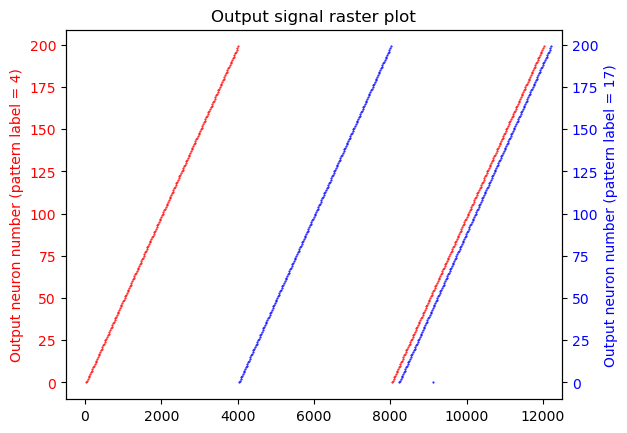

In [80]:
#maximum number of patterns to plot
max_num_figures_spike = 5
num_figures_spike=0
#start time of the plot
t_min = 0
#stop time of the plot
t_max = 120000
color_list = ['r', 'b'] 
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
axes = [ax1, ax2]
for key, value in pattern_detector.data.items():
    '''if key == 'input':
        plt.figure(1)
        for i, spiketrain_i in enumerate(value.segments[0].spiketrains):
            spike_array = spiketrain_i.as_array()
            sub_spike_array = [spike for spike in spike_array if (spike>t_min) and (spike<t_max)]
            plt.scatter(sub_spike_array, i*np.ones(len(sub_spike_array)), marker='.', s=1, c='k', alpha=1)
            plt.xlabel('Time (ms)')
            plt.ylabel('Neuron id')
            plt.title('Input signal raster plot')'''
    if key[:6] == 'output':
        if num_figures_spike<max_num_figures_spike:
            num_figures_spike+=1
            for i, spiketrain_i in enumerate(value.segments[0].spiketrains):
                spike_array = spiketrain_i.as_array()
                sub_spike_array = [spike for spike in spike_array if (spike>t_min) and (spike<t_max)]
                axes[int(key[6:])].scatter(sub_spike_array, i*np.ones(len(sub_spike_array)), marker='.', s=1, c=color_list[int(key[6:])], alpha=1)
                axes[int(key[6:])].set_ylabel('Output neuron number (pattern label = '+str(labels[int(key[6:])])+')', color=color_list[int(key[6:])])
                axes[int(key[6:])].tick_params(axis='y', labelcolor=color_list[int(key[6:])])
plt.xlabel('Time (ms)')
plt.title('Output signal raster plot')
plt.xlim([-500, 12500])


In [ ]:
# timings of the output spikes for each pattern recognition (key is the pattern number)
pattern_detection_dict

{0: [4013.1, 12023.1], 1: [8016.6, 12216.6]}

In [ ]:
# number of output neurons
period_length/20

200.0

### Output neurons' membrane potential plot

Text(-0.03, 0.5, 'Membrane potential (mV) (pattern label = 4)\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n Membrane potential (mV) (pattern label = 17)')

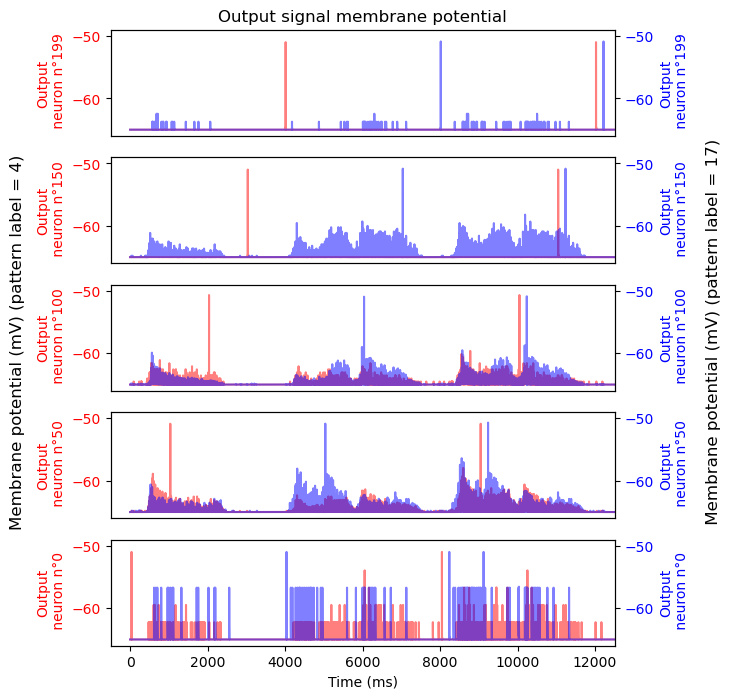

In [178]:
#maximum number of patterns to plot
max_num_figures_membrane_potential = 5
num_figures_membrane_potential=0
#start time of the plot
t_min = 0
#stop time of the plot
t_max = 12500
output_neuron_plots = [199, 150, 100, 50, 0]
num_neurons_output_plot = len(output_neuron_plots)
fig, ax1 = plt.subplots(num_neurons_output_plot)
ax2 = [ax1[i].twinx() for i in range(num_neurons_output_plot)]
axes = [ax1, ax2]
ax1[0].set_title('Output signal membrane potential')
for key, value in pattern_detector.data.items():
    '''if key == 'input':
        plt.rcParams['figure.figsize'] = [10, 1.6*num_sequence]
        fig = plt.figure(1)
        fig.supxlabel('Time (ms)')
        fig.supylabel('Membrane potential (mV)')
        plt.xticks([])
        plt.yticks([])
        plt.axis('off')
        plt.title('Input signal membrane potential')
        v_m = value.segments[0].analogsignals
        for array in v_m:
            for i in range(array.shape[1]):
                plt.subplot(array.shape[1], 1, i+1)
                plt.plot(array.times, array[:, i], label='neuron_%i' %i)
                plt.xlim(t_min,t_max)
                plt.ylim(-66,-49)
                plt.ylabel('Input\n neuron n°'+str(i))'''
    if key[:6] == 'output':
        plt.rcParams['figure.figsize'] = [6.5, 1.6*num_neurons_output_plot]
        if num_figures_membrane_potential<max_num_figures_membrane_potential:
            num_figures_membrane_potential+=1
            v_m = value.segments[0].analogsignals
            for array in v_m:
                for i in range(num_neurons_output_plot):
                    axes[int(key[6:])][i].plot(array.times, array[:, output_neuron_plots[i]], label='neuron_%i' %output_neuron_plots[i], c=color_list[int(key[6:])], alpha=0.5)
                    #axes[int(key[6:])][i].set_xlim(t_min,t_max)
                    axes[int(key[6:])][i].set_ylim(-66,-49)
                    axes[int(key[6:])][i].set_ylabel('Output\n neuron n°'+str(output_neuron_plots[i]), color=color_list[int(key[6:])])
                    axes[int(key[6:])][i].set_xlim([-500, 12500])
                    axes[int(key[6:])][i].tick_params(axis='y', labelcolor=color_list[int(key[6:])])
                    if i != num_neurons_output_plot-1:
                        axes[int(key[6:])][i].set_xticks([])
                    else:
                        axes[int(key[6:])][i].set_xlabel('Time (ms)')
fig.supylabel('Membrane potential (mV) (pattern label = '+str(labels[0])+')\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n Membrane potential (mV) (pattern label = '+str(labels[1])+')', x=-0.03)


In [ ]:
#maximum number of patterns to plot
max_num_figures_membrane_potential = 5
num_figures_membrane_potential=0
#start time of the plot
t_min = 0
#stop time of the plot
t_max = 12500
output_neuron_plots = [i for i in range(200)]
num_neurons_output_plot = len(output_neuron_plots)
fig, ax1 = plt.subplots(1)
ax1.set_title('Output signal membrane potential')
for key, value in pattern_detector.data.items():
    '''if key == 'input':
        plt.rcParams['figure.figsize'] = [10, 1.6*num_sequence]
        fig = plt.figure(1)
        fig.supxlabel('Time (ms)')
        fig.supylabel('Membrane potential (mV)')
        plt.xticks([])
        plt.yticks([])
        plt.axis('off')
        plt.title('Input signal membrane potential')
        v_m = value.segments[0].analogsignals
        for array in v_m:
            for i in range(array.shape[1]):
                plt.subplot(array.shape[1], 1, i+1)
                plt.plot(array.times, array[:, i], label='neuron_%i' %i)
                plt.xlim(t_min,t_max)
                plt.ylim(-66,-49)
                plt.ylabel('Input\n neuron n°'+str(i))'''
    if key[:6] == 'output' and int(key[6:]) == 0:
        ax1.set_title('Output signal membrane potential (pattern label='+str(labels[int(key[6:])])+')')
        plt.rcParams['figure.figsize'] = [8, 15]
        if num_figures_membrane_potential<max_num_figures_membrane_potential:
            num_figures_membrane_potential+=1
            v_m = value.segments[0].analogsignals
            for array in v_m:
                for i in range(num_neurons_output_plot):
                    ax1.plot(array.times, array[:, output_neuron_plots[i]].as_array()+6*i, label='neuron_%i' %output_neuron_plots[i], c='r')
                    #axes[int(key[6:])][i].set_xlim(t_min,t_max)
                    #axes[int(key[6:])][i].set_ylim(-66,-49)
                    ax1.set_xlim([-500, 12500])
                    ax1.tick_params(axis='y', labelcolor=color_list[int(key[6:])])
                    ax1.set_xticks([])
                    ax1.set_yticks([])
                    ax1.axis('off')



### Waterfall visualization of the output membrane potentials

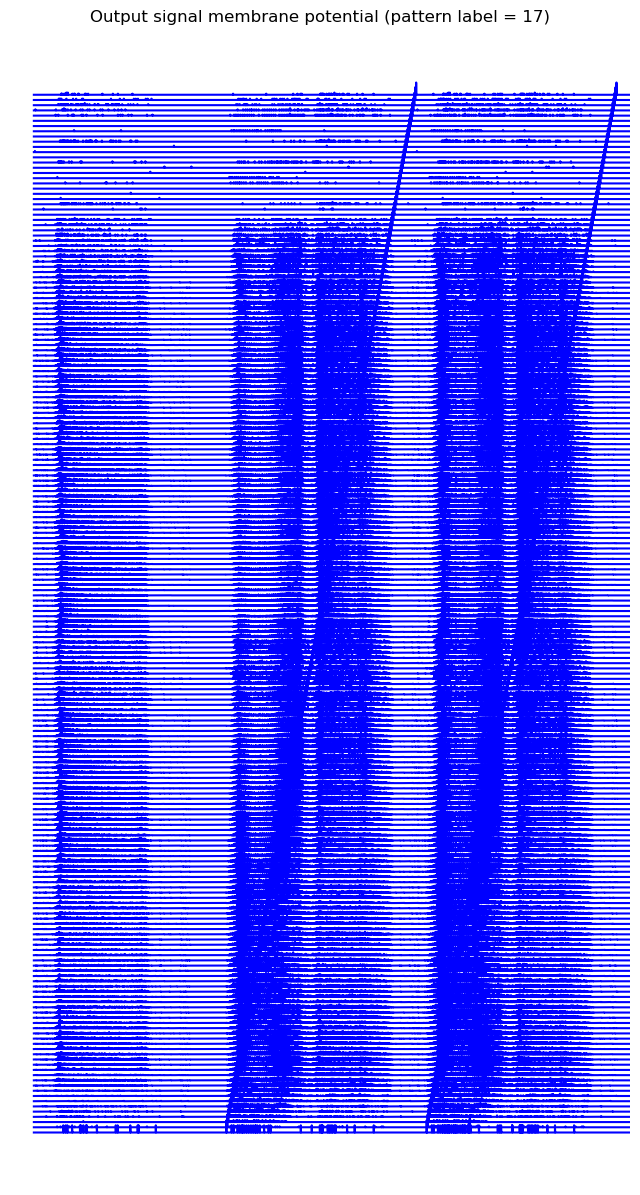

: 

In [ ]:
#maximum number of patterns to plot
max_num_figures_membrane_potential = 5
num_figures_membrane_potential=0
#start time of the plot
t_min = 0
#stop time of the plot
t_max = 12500
output_neuron_plots = [i for i in range(200)]
num_neurons_output_plot = len(output_neuron_plots)
fig, ax1 = plt.subplots(1)

for key, value in pattern_detector.data.items():
    '''if key == 'input':
        plt.rcParams['figure.figsize'] = [10, 1.6*num_sequence]
        fig = plt.figure(1)
        fig.supxlabel('Time (ms)')
        fig.supylabel('Membrane potential (mV)')
        plt.xticks([])
        plt.yticks([])
        plt.axis('off')
        plt.title('Input signal membrane potential')
        v_m = value.segments[0].analogsignals
        for array in v_m:
            for i in range(array.shape[1]):
                plt.subplot(array.shape[1], 1, i+1)
                plt.plot(array.times, array[:, i], label='neuron_%i' %i)
                plt.xlim(t_min,t_max)
                plt.ylim(-66,-49)
                plt.ylabel('Input\n neuron n°'+str(i))'''
    if key[:6] == 'output' and int(key[6:]) == 1:
        ax1.set_title('Output signal membrane potential (pattern label = '+str(labels[int(key[6:])])+')')
        plt.rcParams['figure.figsize'] = [8, 15]
        if num_figures_membrane_potential<max_num_figures_membrane_potential:
            num_figures_membrane_potential+=1
            v_m = value.segments[0].analogsignals
            for array in v_m:
                for i in range(num_neurons_output_plot):
                    ax1.plot(array.times, array[:, output_neuron_plots[i]].as_array()+6*i, label='neuron_%i' %output_neuron_plots[i], c='b')
                    #axes[int(key[6:])][i].set_xlim(t_min,t_max)
                    #axes[int(key[6:])][i].set_ylim(-66,-49)
                    ax1.set_xlim([-500, 12500])
                    ax1.tick_params(axis='y', labelcolor=color_list[int(key[6:])])
                    ax1.set_xticks([])
                    ax1.set_yticks([])
                    ax1.axis('off')

